In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.methods.cannon import (
    train_cannon,
    _build_cannon_design_matrix,
)
from ugdatalab.models.apogee.constants import LABEL_NAMES

import plotters

In [2]:
data = np.load("training_spectra.npz", allow_pickle=True)
flux = data["flux"]
error = data["error"]
labels = data["labels"]
wavelength = data["wavelength"]
apogee_ids = data["apogee_ids"]
label_names = list(data["label_names"])

print(f"Loaded: {flux.shape[0]} stars, {flux.shape[1]} pixels")
print(f"Labels: {label_names}")

Loaded: 1886 stars, 8575 pixels
Labels: [np.str_('TEFF'), np.str_('LOGG'), np.str_('FE_H'), np.str_('MG_FE'), np.str_('SI_FE')]


## Problem 5 — Train/CV Split

We split the training set 50/50 into a training subset and a cross-validation subset with a fixed random seed for reproducibility.

In [3]:
N = flux.shape[0]
rng = np.random.default_rng(seed=42)
idx = rng.permutation(N)
n_train = N // 2

train_idx = np.sort(idx[:n_train])
cv_idx = np.sort(idx[n_train:])

flux_train, error_train, labels_train = flux[train_idx], error[train_idx], labels[train_idx]
flux_cv, error_cv, labels_cv = flux[cv_idx], error[cv_idx], labels[cv_idx]

print(f"Training: {len(train_idx)} stars")
print(f"Cross-validation: {len(cv_idx)} stars")

Training: 943 stars
Cross-validation: 943 stars


## Problem 6 — The Cannon Model

### 6a — Design matrix

The spectral model at pixel $\lambda$ is:

$$f_\lambda = \mathbf{X}_n \cdot \boldsymbol{\theta}_\lambda$$

where $\mathbf{X}_n$ is the design vector for star $n$ — a 2nd-order polynomial in 5 labels giving 21 terms:

$$\mathbf{X}_n = [1,\; \ell_1,\; \ell_2,\; \ell_3,\; \ell_4,\; \ell_5,\; \ell_1^2,\; \ell_1\ell_2,\; \ldots,\; \ell_5^2]$$

where $\ell_i$ are labels centered by their mean and scaled by their standard deviation.

In [4]:
# Build and display the design matrix structure
label_means = np.mean(labels_train, axis=0)
label_stds = np.std(labels_train, axis=0)
scaled = (labels_train - label_means) / label_stds
X = _build_cannon_design_matrix(scaled)

# Column labels
col_labels = ["1"]
for name in LABEL_NAMES:
    col_labels.append(name)
for i, ni in enumerate(LABEL_NAMES):
    for j, nj in enumerate(LABEL_NAMES):
        if j >= i:
            col_labels.append(f"{ni}*{nj}" if i != j else f"{ni}^2")

print(f"Design matrix shape: {X.shape}")
print(f"Column labels ({len(col_labels)}): {col_labels}")
pd.DataFrame(X[:5], columns=col_labels).round(3)

Design matrix shape: (943, 21)
Column labels (21): ['1', 'TEFF', 'LOGG', 'FE_H', 'MG_FE', 'SI_FE', 'TEFF^2', 'TEFF*LOGG', 'TEFF*FE_H', 'TEFF*MG_FE', 'TEFF*SI_FE', 'LOGG^2', 'LOGG*FE_H', 'LOGG*MG_FE', 'LOGG*SI_FE', 'FE_H^2', 'FE_H*MG_FE', 'FE_H*SI_FE', 'MG_FE^2', 'MG_FE*SI_FE', 'SI_FE^2']


,1,TEFF,LOGG,FE_H,MG_FE,SI_FE,TEFF^2,TEFF*LOGG,TEFF*FE_H,TEFF*MG_FE,...,LOGG^2,LOGG*FE_H,LOGG*MG_FE,LOGG*SI_FE,FE_H^2,FE_H*MG_FE,FE_H*SI_FE,MG_FE^2,MG_FE*SI_FE,SI_FE^2
0,1.0,0.119,0.440,0.800,-0.762,-0.841,0.014,0.052,0.095,-0.091,...,0.194,0.352,-0.335,-0.370,0.640,-0.610,-0.673,0.581,0.641,0.708
1,1.0,-0.260,-0.369,0.563,-0.908,-0.633,0.068,0.096,-0.146,0.236,...,0.136,-0.208,0.335,0.233,0.317,-0.511,-0.356,0.824,0.574,0.400
2,1.0,-1.335,-1.043,0.738,-0.990,-1.108,1.783,1.393,-0.985,1.322,...,1.088,-0.769,1.033,1.155,0.544,-0.730,-0.817,0.981,1.097,1.228
3,1.0,-1.334,-1.384,0.167,-0.777,-0.623,1.779,1.846,-0.223,1.036,...,1.915,-0.231,1.075,0.863,0.028,-0.130,-0.104,0.603,0.484,0.389
4,1.0,-0.926,-0.598,0.820,-0.671,-0.379,0.857,0.554,-0.759,0.622,...,0.358,-0.490,0.402,0.227,0.672,-0.550,-0.311,0.451,0.254,0.144


In [5]:
n_coefficients = X.shape[1]  # 21
n_pixels = wavelength.shape[0]  # 8575
n_params_total = (n_coefficients + 1) * n_pixels  # +1 for scatter per pixel
print(f"Coefficients per pixel: {n_coefficients}")
print(f"Number of pixels: {n_pixels}")
print(f"Total free parameters: {n_params_total:,}  ({n_coefficients} + 1 scatter) × {n_pixels}")

Coefficients per pixel: 21
Number of pixels: 8575
Total free parameters: 188,650  (21 + 1 scatter) × 8575


### 6b — Log-likelihood and training procedure

The full log-likelihood across all stars $n$ and pixels $\lambda$ is:

$$\ln \mathcal{L} = -\frac{1}{2}\sum_n \sum_\lambda \left[\ln\bigl(2\pi(\sigma_{n\lambda}^2 + s_\lambda^2)\bigr) + \frac{(f_{n\lambda} - \mathbf{X}_n \cdot \boldsymbol{\theta}_\lambda)^2}{\sigma_{n\lambda}^2 + s_\lambda^2}\right]$$

where $\sigma_{n\lambda}$ is the measurement error and $s_\lambda^2$ is the per-pixel intrinsic scatter (model inadequacy). The scatter term makes the problem nonlinear — we cannot solve for all parameters via matrix algebra alone.

**Profile likelihood trick**: For fixed $s_\lambda^2$, the optimal $\boldsymbol{\theta}_\lambda$ is the weighted least-squares (WLS) solution with weights $w_{n\lambda} = 1/(\sigma_{n\lambda}^2 + s_\lambda^2)$. We optimize the scalar $\log s_\lambda^2$ via bounded 1D minimization, solving WLS analytically at each function evaluation. Each pixel is trained independently.

### Scatter floor: preventing overfitting at chip edges

The optimizer searches for $\log s_\lambda^2$ within a bounded interval. Without care, the lower bound can permit unphysically small scatter values, particularly at wavelengths near the edges of APOGEE's three detector chips.

**The problem.** At chip boundaries, most stars have their pixels flagged by the bitmask (bad flat-field, no data) or have inflated errors from continuum normalization artifacts. A pixel that retains only 50--100 usable training stars out of 1886 is effectively underconstrained: 21 polynomial coefficients can fit the available data almost exactly, leaving near-zero residuals. The optimizer interprets this as $s_\lambda^2 \approx 0$ --- the model appears to explain the data perfectly. In reality, the $\boldsymbol{\theta}_\lambda$ coefficients at these pixels are dominated by noise in the few available stars, not by physical label dependence.

**Why this matters downstream.** The gradient spectrum $\partial f_\lambda / \partial \ell_i$ is computed directly from $\boldsymbol{\theta}_\lambda$. When the coefficients are noise-driven, the gradient exhibits sharp, unphysical spikes at chip edges that can dominate the plot and obscure real spectral features. The intrinsic scatter spectrum $s_\lambda$ also drops to the optimizer floor at these wavelengths, giving the false impression that the model is most accurate precisely where it is least trustworthy.

**Physical motivation for a floor.** The intrinsic scatter $s_\lambda^2$ represents model inadequacy --- variance in the true flux that the 2nd-order polynomial cannot capture. Every pixel has some irreducible contribution from:

1. **Higher-order label dependence**: the true mapping from labels to flux involves terms beyond quadratic (e.g., the nonlinear temperature sensitivity of molecular equilibria in cool giants).
2. **Missing labels**: the model uses 5 labels, but real spectra depend on additional parameters (microturbulence, C/N ratio, rotational broadening) that vary across the training set.
3. **Continuum normalization residuals**: the per-chip Chebyshev fits leave percent-level systematics that correlate with chip position and stellar type.

These contributions are at least comparable to the measurement noise $\sigma_{n\lambda}^2$. Setting $s_\lambda^2 < \sigma_{n\lambda}^2$ would imply the model is more precise than the data --- a claim that cannot be supported.

**Implementation.** We set the lower bound of the $\log s_\lambda^2$ optimization to $\log(\mathrm{median}(\sigma_{n\lambda}^2))$ at each pixel, where the median is taken over all valid training stars. This enforces:

$$s_\lambda^2 \geq \mathrm{median}_n\left(\sigma_{n\lambda}^2\right)$$

The floor is data-driven (adapts to the noise level at each wavelength), conservative (the median is robust to outlier errors), and physically motivated (model inadequacy should not be smaller than measurement precision). At well-sampled pixels in the chip interiors, the optimizer finds $s_\lambda^2$ well above the floor, so the constraint is inactive and the fit is unchanged.

### 6c — Train The Cannon

In [6]:
model = train_cannon(flux_train, error_train, labels_train, wavelength,
                     label_names=list(LABEL_NAMES))
print(f"theta shape: {model.theta.shape}")
print(f"scatter shape: {model.scatter.shape}")
print(f"Training chi2_r: {model.chi2_r:.3f}")

theta shape: (8575, 21)
scatter shape: (8575,)
Training chi2_r: 1.007


### 6d — Prediction demonstration

In [7]:
predicted = model.predict(labels_train[0])
print(f"Input: labels shape {labels_train[0].shape}")
print(f"Output: spectrum shape {predicted.shape}")

Input: labels shape (5,)
Output: spectrum shape (8575,)


## Problem 7 — Training Validation

We compare the Cannon's prediction for a training star against its observed spectrum in the 16000–16100 Å window.

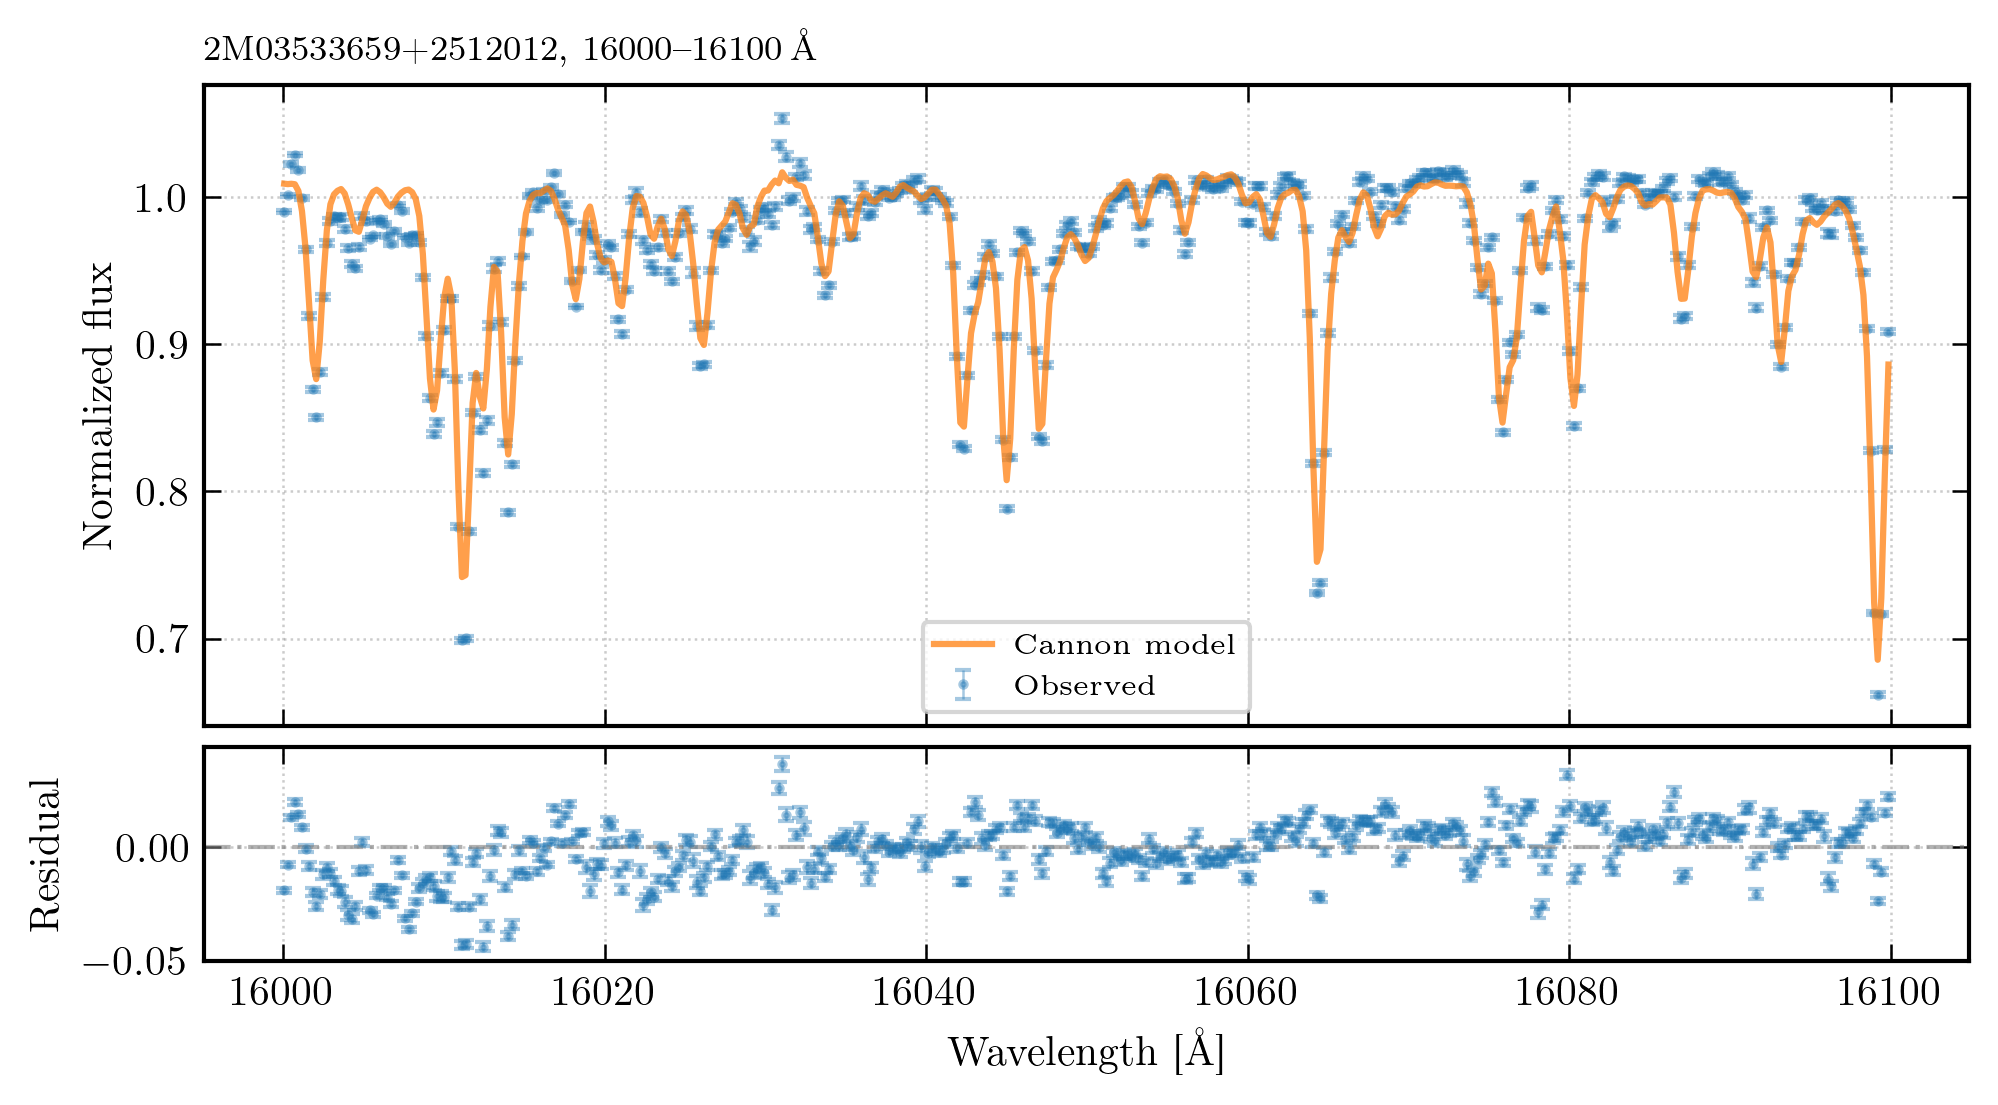

In [8]:
target_id = "2M03533659+2512012"
train_ids = apogee_ids[train_idx]
match = np.where(np.array(train_ids, dtype=str) == target_id)[0]

if len(match) > 0:
    star_idx = match[0]
    flux_obs = flux_train[star_idx]
    error_obs = error_train[star_idx]
    flux_pred = model.predict(labels_train[star_idx])

    axes = plotters.plot_training_prediction(
        wavelength, flux_obs, error_obs, flux_pred,
        apogee_id=target_id, wl_min=16000, wl_max=16100,
    )
    plt.show()
else:
    print(f"{target_id} not in training set; trying first training star instead")
    flux_obs = flux_train[0]
    error_obs = error_train[0]
    flux_pred = model.predict(labels_train[0])

    axes = plotters.plot_training_prediction(
        wavelength, flux_obs, error_obs, flux_pred,
        apogee_id=str(train_ids[0]), wl_min=16000, wl_max=16100,
    )
    plt.show()

## Problem 8 — Model Interpretation

### 8a — Gradient spectra

The gradient spectrum $\partial f_\lambda / \partial \ell_i$ shows how the predicted flux at each pixel changes with a given stellar label, evaluated at the training-set mean. Peaks in these gradients identify spectral features sensitive to that label.

We mark known Mg I lines (15745.0, 15753.3, 15770.1 Å vacuum; NIST ASD) on the [Mg/Fe] panel and Si I lines (15892.7, 16064.4, 16099.2, 16168.1, 16220.1 Å vacuum; NIST ASD) on the [Si/Fe] panel.

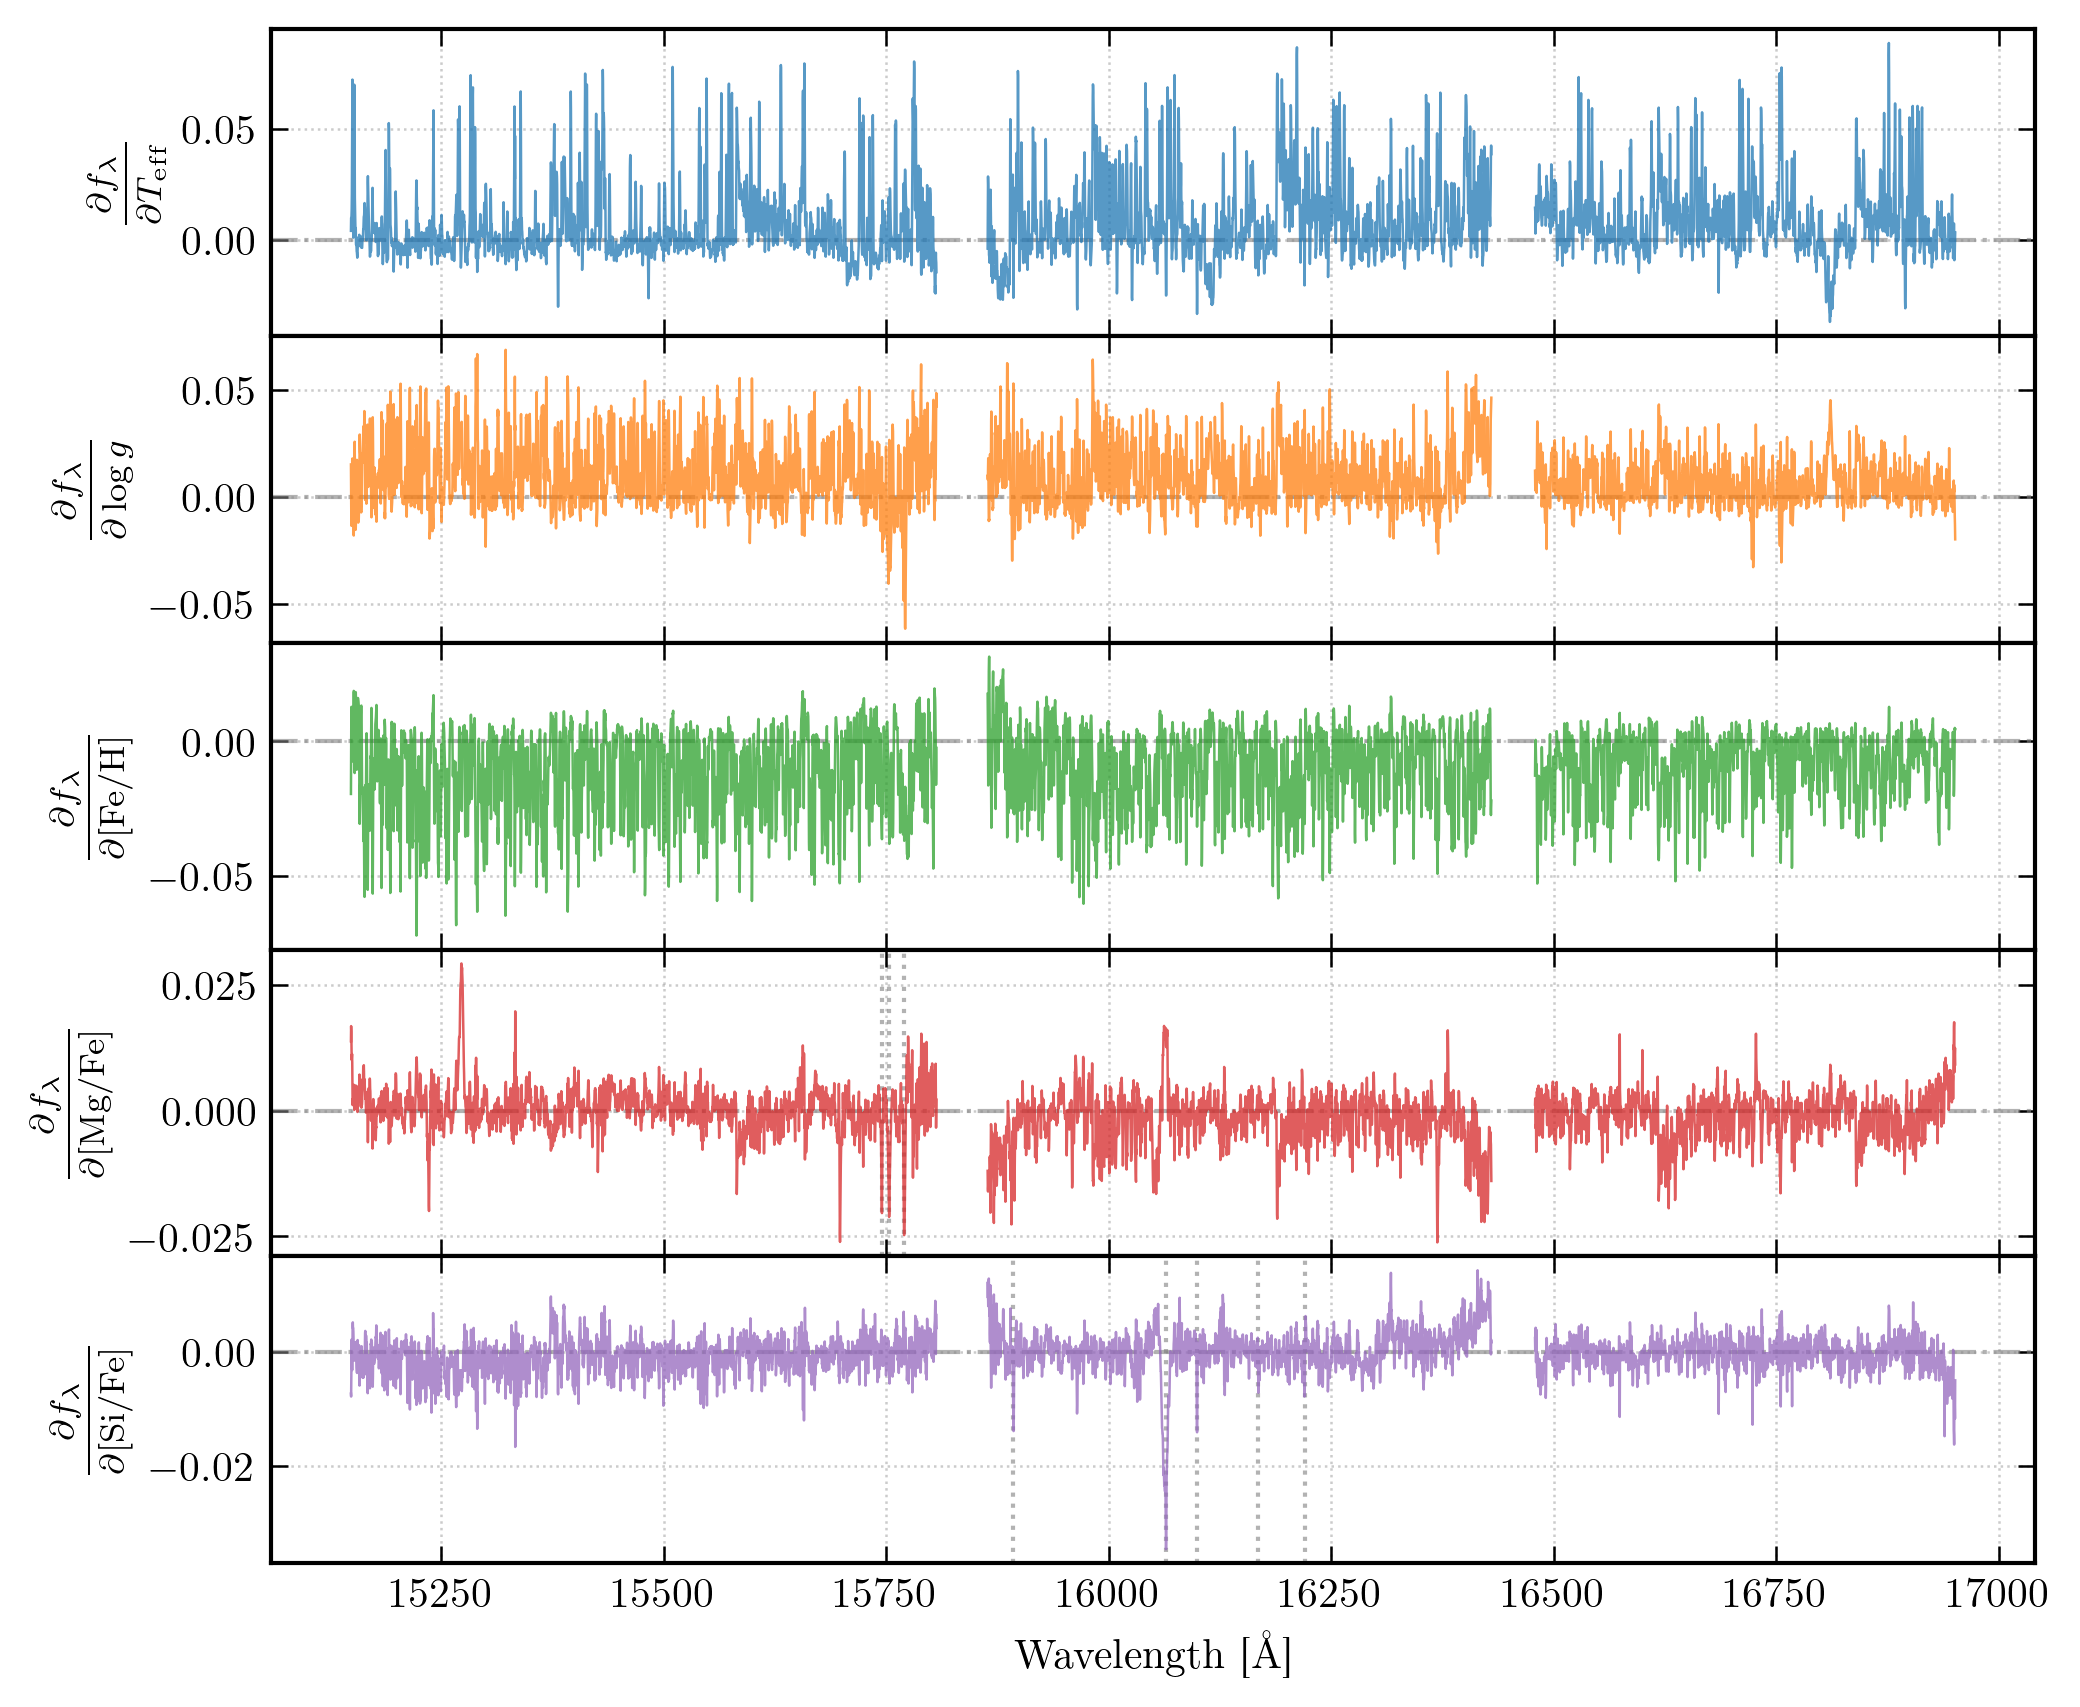

In [9]:
axes = plotters.plot_gradient_spectra(model)
plt.show()

### 8b — Scatter spectrum

The per-pixel intrinsic scatter $s_\lambda$ quantifies how much additional variance beyond measurement error is needed to explain the training data. High-scatter regions correspond to strong absorption lines where the 2nd-order polynomial model is insufficient — the true line profile dependence on labels is more complex than a quadratic can capture.

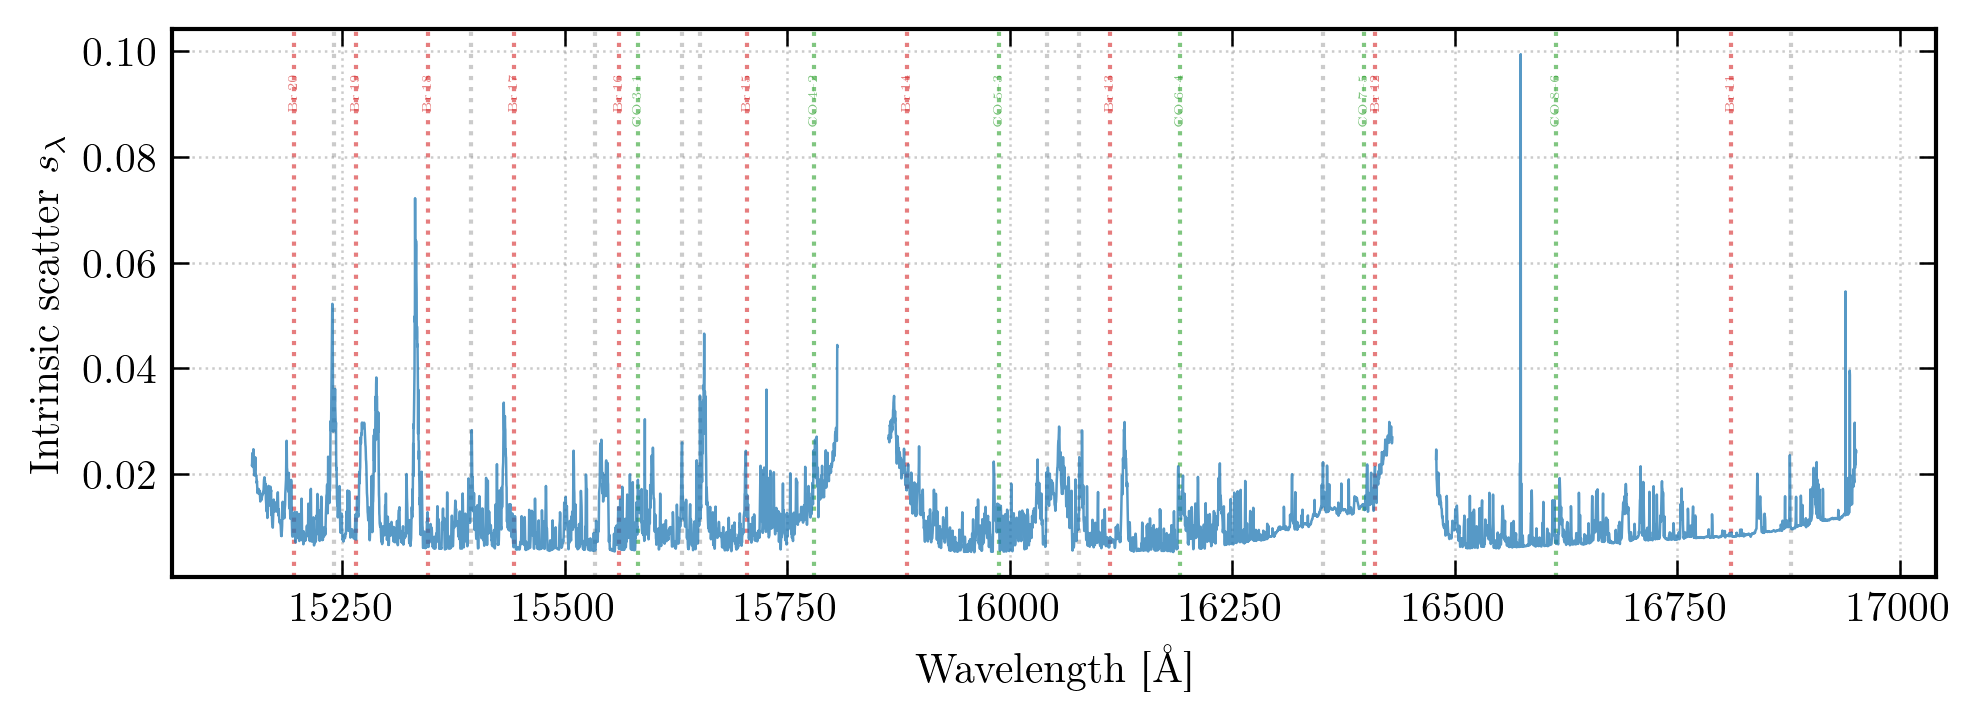

In [10]:
ax = plotters.plot_scatter_spectrum(model)
plt.show()

### Scatter spectrum analysis

The larger-than-average scatter regions fall into three categories:

**Genuine model inadequacy at strong absorption lines.** The 2nd-order polynomial cannot capture the nonlinear label dependence of deep spectral features. The dominant contributors are:

- **Brackett hydrogen series** (Br12–Br20, ~15196–16411 Å; NIST ASD): pressure-broadened lines whose profiles depend on $T_{\rm eff}$ and $\log g$ in a way that is poorly approximated by a quadratic. The broad wings blend with neighboring features, further complicating the polynomial fit.
- **CO first-overtone bandheads** (~15582, 15780, 16398 Å; Kleinmann & Hall 1986, Wallace & Hinkle 1997): molecular equilibrium is a steep function of $T_{\rm eff}$ — CO dissociates rapidly above ~4500 K, creating a near-discontinuous label dependence that no polynomial can follow.
- **Strong Fe I lines** (~15240, 15395, 15534, 15632, 15652, 16078, 16352, 16878 Å; Shetrone et al. 2015, Smith et al. 2021) and **Mg I** (15745, 15753, 15770 Å; NIST ASD), **Si I** (15893, 16064 Å; NIST ASD): saturated lines whose equivalent widths respond nonlinearly to abundance changes.

**Chip-edge artifacts.** The broad elevated region at ~15795–15882 Å coincides with the right edge of the blue chip, where few training stars contribute valid data.

 Although the valid-fraction cut removes the worst pixels, the transition zone retains marginal data quality that inflates the scatter. A similar but narrower feature appears near the green chip right edge (~16415–16480 Å).

**Unflagged single-star outliers.** A sharp spike at ~16574 Å is driven by one star (2M21290172+1332232) with a 2-pixel negative flux artifact ($f \approx -2$ on a normalized scale of $\sim 1$). The raw APOGEE coadded spectrum shows flux jumping from $+162$ to $-330$ and back within 2 pixels, with no bitmask bits set and a normal error of $\sim 3$. This is a cosmic ray or detector artifact that escaped the APOGEE pipeline's up-the-ramp rejection. Removing this single star would reduce the scatter at this wavelength from $s_\lambda = 0.099$ to $s_\lambda = 0.013$, consistent with the surrounding continuum. Similar isolated spikes at ~16939 Å likely have the same origin.

### Save trained model

In [11]:
np.savez_compressed(
    "cannon_model.npz",
    theta=model.theta,
    scatter=model.scatter,
    label_means=model.label_means,
    label_stds=model.label_stds,
    wavelength=model.wavelength,
    label_names=np.array(model.label_names),
    chi2_r=np.array(model.chi2_r),
    train_idx=train_idx,
    cv_idx=cv_idx,
)
print("Saved cannon_model.npz")
print(f"  theta: {model.theta.shape}")
print(f"  scatter: {model.scatter.shape}")
print(f"  chi2_r: {model.chi2_r:.3f}")
print(f"  train_idx: {train_idx.shape}")
print(f"  cv_idx: {cv_idx.shape}")

Saved cannon_model.npz
  theta: (8575, 21)
  scatter: (8575,)
  chi2_r: 1.007
  train_idx: (943,)
  cv_idx: (943,)
